In [3]:
import pandas as pd

file_path = "/content/online_retail_II.xlsx"

xls = pd.ExcelFile(file_path)

print(xls.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [5]:
import pandas as pd

file_path = "/content/online_retail_II.xlsx"

df_2009_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010",
    engine="openpyxl"
)

print("First sheet loaded:", df_2009_2010.shape)

First sheet loaded: (525461, 8)


In [6]:
df_2010_2011 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011",
    engine="openpyxl"
)

print("Second sheet loaded:", df_2010_2011.shape)

Second sheet loaded: (541910, 8)


In [7]:
df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print("Combined dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Combined dataset shape: (1067371, 8)

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [8]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Duplicate rows: 34335

Data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [9]:
# Make a copy before cleaning
df_clean = df.copy()

# Convert InvoiceDate to datetime
df_clean["InvoiceDate"] = pd.to_datetime(
    df_clean["InvoiceDate"],
    errors="coerce"
)

# Remove missing Customer IDs
df_clean = df_clean.dropna(subset=["Customer ID"])

# Remove cancelled invoices
df_clean = df_clean[
    ~df_clean["Invoice"].astype(str).str.startswith("C")
]

# Keep only positive quantities
df_clean = df_clean[df_clean["Quantity"] > 0]

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

print("Cleaned dataset shape:", df_clean.shape)
print("\nMissing Customer IDs:", df_clean["Customer ID"].isna().sum())
print("\nDate range:")
print(df_clean["InvoiceDate"].min(), "to", df_clean["InvoiceDate"].max())

Cleaned dataset shape: (779495, 8)

Missing Customer IDs: 0

Date range:
2009-12-01 07:45:00 to 2011-12-09 12:50:00


In [10]:
first_purchase = (
    df_clean.groupby("Customer ID")["InvoiceDate"]
    .min()
    .reset_index()
)

first_purchase.columns = ["Customer ID", "FirstPurchaseDate"]

print(first_purchase.head())

   Customer ID   FirstPurchaseDate
0      12346.0 2009-12-14 08:34:00
1      12347.0 2010-10-31 14:20:00
2      12348.0 2010-09-27 14:59:00
3      12349.0 2010-04-29 13:20:00
4      12350.0 2011-02-02 16:01:00


In [11]:
first_purchase["CohortMonth"] = (
    first_purchase["FirstPurchaseDate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

print(first_purchase.head())

   Customer ID   FirstPurchaseDate CohortMonth
0      12346.0 2009-12-14 08:34:00  2009-12-01
1      12347.0 2010-10-31 14:20:00  2010-10-01
2      12348.0 2010-09-27 14:59:00  2010-09-01
3      12349.0 2010-04-29 13:20:00  2010-04-01
4      12350.0 2011-02-02 16:01:00  2011-02-01


In [12]:
# Convert each transaction date to its month
df_clean["ActivityMonth"] = (
    df_clean["InvoiceDate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Add each customer's cohort month
df_clean = df_clean.merge(
    first_purchase[["Customer ID", "CohortMonth"]],
    on="Customer ID",
    how="left"
)

print(df_clean[
    ["Customer ID", "InvoiceDate", "ActivityMonth", "CohortMonth"]
].head())

   Customer ID         InvoiceDate ActivityMonth CohortMonth
0      13085.0 2009-12-01 07:45:00    2009-12-01  2009-12-01
1      13085.0 2009-12-01 07:45:00    2009-12-01  2009-12-01
2      13085.0 2009-12-01 07:45:00    2009-12-01  2009-12-01
3      13085.0 2009-12-01 07:45:00    2009-12-01  2009-12-01
4      13085.0 2009-12-01 07:45:00    2009-12-01  2009-12-01


In [13]:
df_clean["CohortIndex"] = (
    (df_clean["ActivityMonth"].dt.year - df_clean["CohortMonth"].dt.year) * 12
    + (df_clean["ActivityMonth"].dt.month - df_clean["CohortMonth"].dt.month)
    + 1
)

print(
    df_clean[
        ["Customer ID", "CohortMonth", "ActivityMonth", "CohortIndex"]
    ].head(10)
)

   Customer ID CohortMonth ActivityMonth  CohortIndex
0      13085.0  2009-12-01    2009-12-01            1
1      13085.0  2009-12-01    2009-12-01            1
2      13085.0  2009-12-01    2009-12-01            1
3      13085.0  2009-12-01    2009-12-01            1
4      13085.0  2009-12-01    2009-12-01            1
5      13085.0  2009-12-01    2009-12-01            1
6      13085.0  2009-12-01    2009-12-01            1
7      13085.0  2009-12-01    2009-12-01            1
8      13085.0  2009-12-01    2009-12-01            1
9      13085.0  2009-12-01    2009-12-01            1


In [14]:
cohort_data = (
    df_clean
    .groupby(["CohortMonth", "CohortIndex"])["Customer ID"]
    .nunique()
    .reset_index()
)

print(cohort_data.head(10))

  CohortMonth  CohortIndex  Customer ID
0  2009-12-01            1          955
1  2009-12-01            2          337
2  2009-12-01            3          319
3  2009-12-01            4          406
4  2009-12-01            5          363
5  2009-12-01            6          343
6  2009-12-01            7          360
7  2009-12-01            8          327
8  2009-12-01            9          321
9  2009-12-01           10          346


In [15]:
cohort_table = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="Customer ID"
)

print(cohort_table)

CohortIndex     1      2      3      4      5      6      7      8      9   \
CohortMonth                                                                  
2009-12-01   955.0  337.0  319.0  406.0  363.0  343.0  360.0  327.0  321.0   
2010-01-01   383.0   79.0  119.0  117.0  101.0  115.0   99.0   88.0  107.0   
2010-02-01   376.0   89.0   84.0  109.0   92.0   75.0   72.0  107.0   95.0   
2010-03-01   443.0   84.0  102.0  107.0  103.0   90.0  109.0  134.0  122.0   
2010-04-01   294.0   57.0   57.0   48.0   54.0   66.0   81.0   77.0   31.0   
2010-05-01   254.0   40.0   43.0   44.0   45.0   65.0   54.0   32.0   15.0   
2010-06-01   270.0   47.0   51.0   55.0   62.0   77.0   34.0   24.0   22.0   
2010-07-01   186.0   29.0   34.0   55.0   54.0   26.0   21.0   27.0   27.0   
2010-08-01   162.0   33.0   48.0   52.0   28.0   19.0   16.0   20.0   22.0   
2010-09-01   243.0   55.0   57.0   30.0   22.0   25.0   33.0   24.0   31.0   
2010-10-01   377.0   97.0   55.0   47.0   33.0   31.0   49.0   5

In [16]:
cohort_retention = cohort_table.divide(
    cohort_table.iloc[:, 0],
    axis=0
) * 100

print(cohort_retention.round(2))

CohortIndex     1      2      3      4      5      6      7      8      9   \
CohortMonth                                                                  
2009-12-01   100.0  35.29  33.40  42.51  38.01  35.92  37.70  34.24  33.61   
2010-01-01   100.0  20.63  31.07  30.55  26.37  30.03  25.85  22.98  27.94   
2010-02-01   100.0  23.67  22.34  28.99  24.47  19.95  19.15  28.46  25.27   
2010-03-01   100.0  18.96  23.02  24.15  23.25  20.32  24.60  30.25  27.54   
2010-04-01   100.0  19.39  19.39  16.33  18.37  22.45  27.55  26.19  10.54   
2010-05-01   100.0  15.75  16.93  17.32  17.72  25.59  21.26  12.60   5.91   
2010-06-01   100.0  17.41  18.89  20.37  22.96  28.52  12.59   8.89   8.15   
2010-07-01   100.0  15.59  18.28  29.57  29.03  13.98  11.29  14.52  14.52   
2010-08-01   100.0  20.37  29.63  32.10  17.28  11.73   9.88  12.35  13.58   
2010-09-01   100.0  22.63  23.46  12.35   9.05  10.29  13.58   9.88  12.76   
2010-10-01   100.0  25.73  14.59  12.47   8.75   8.22  13.00  13

In [17]:
cohort_retention.round(2)

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12-01,100.0,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,...,30.26,26.28,30.26,28.27,25.97,25.55,31.52,30.47,40.73,19.69
2010-01-01,100.0,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,...,15.14,23.50,19.84,18.54,19.58,24.28,19.32,24.54,5.74,NaN
2010-02-01,100.0,23.67,22.34,28.99,24.47,19.95,19.15,28.46,25.27,27.39,...,19.95,15.96,16.22,14.36,22.87,22.87,16.22,5.85,NaN,NaN
2010-03-01,100.0,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,10.84,...,16.93,17.38,15.58,17.61,20.09,21.22,7.90,NaN,NaN,NaN
2010-04-01,100.0,19.39,19.39,16.33,18.37,22.45,27.55,26.19,10.54,10.88,...,15.65,13.95,14.97,18.03,22.45,5.78,NaN,NaN,NaN,NaN
2010-05-01,100.0,15.75,16.93,17.32,17.72,25.59,21.26,12.60,5.91,8.27,...,12.60,13.78,16.54,15.35,4.72,NaN,NaN,NaN,NaN,NaN
2010-06-01,100.0,17.41,18.89,20.37,22.96,28.52,12.59,8.89,8.15,11.85,...,12.22,13.33,20.37,5.19,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-01,100.0,15.59,18.28,29.57,29.03,13.98,11.29,14.52,14.52,11.29,...,17.20,23.66,8.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-01,100.0,20.37,29.63,32.10,17.28,11.73,9.88,12.35,13.58,12.96,...,19.75,6.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


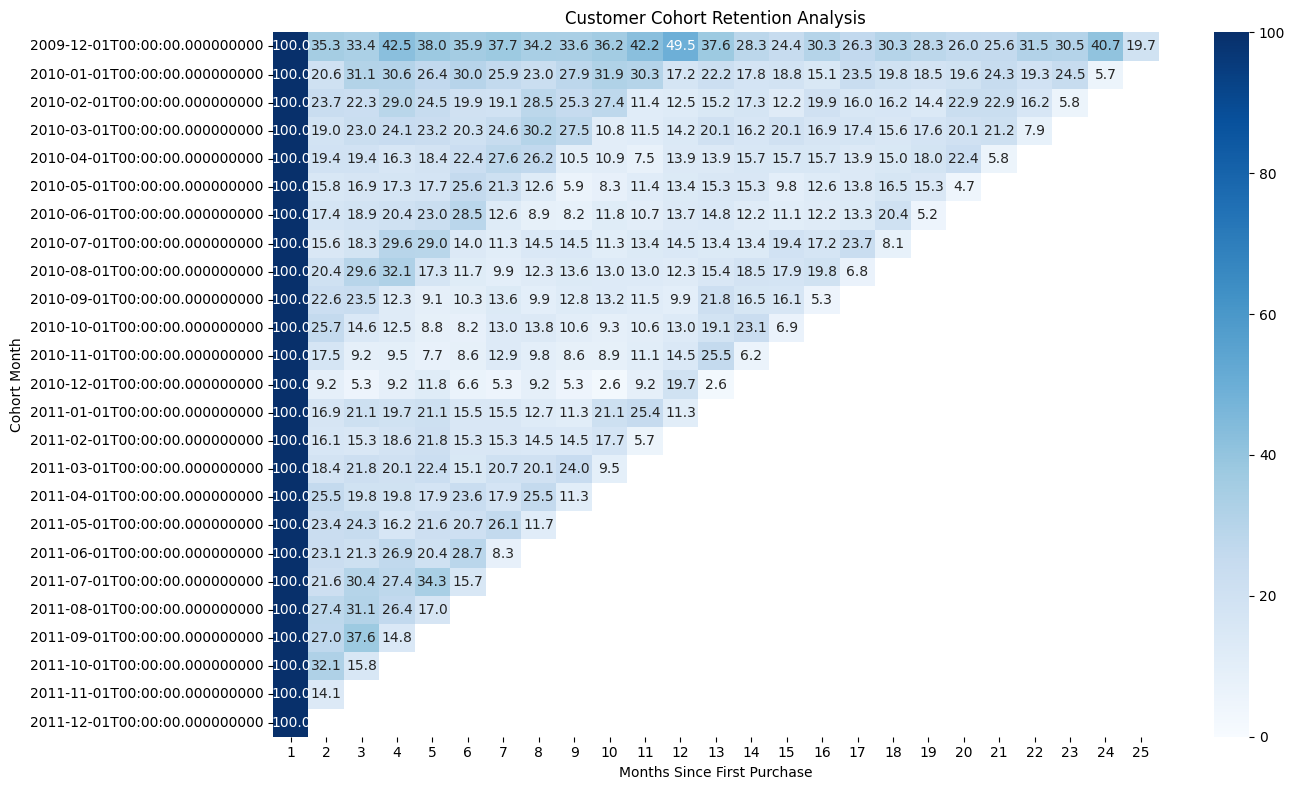

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

sns.heatmap(
    cohort_retention.round(2),
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.title("Customer Cohort Retention Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.tight_layout()
plt.show()

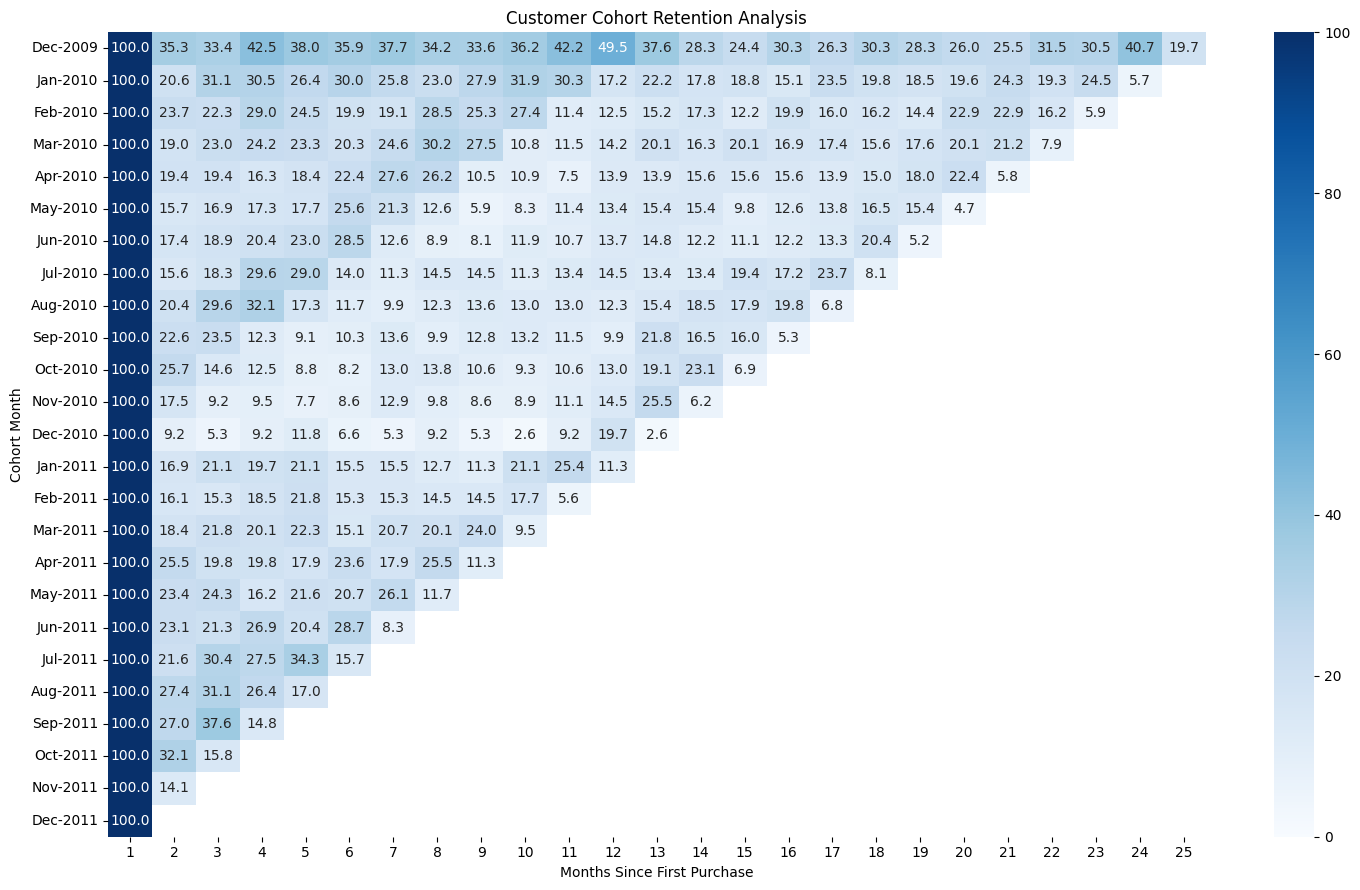

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

heatmap_data = cohort_retention.copy()

heatmap_data.index = heatmap_data.index.strftime("%b-%Y")

plt.figure(figsize=(15, 9))

sns.heatmap(
    heatmap_data.round(1),
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.title("Customer Cohort Retention Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.tight_layout()
plt.show()

In [20]:
plt.savefig(
    "/content/cohort_retention_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

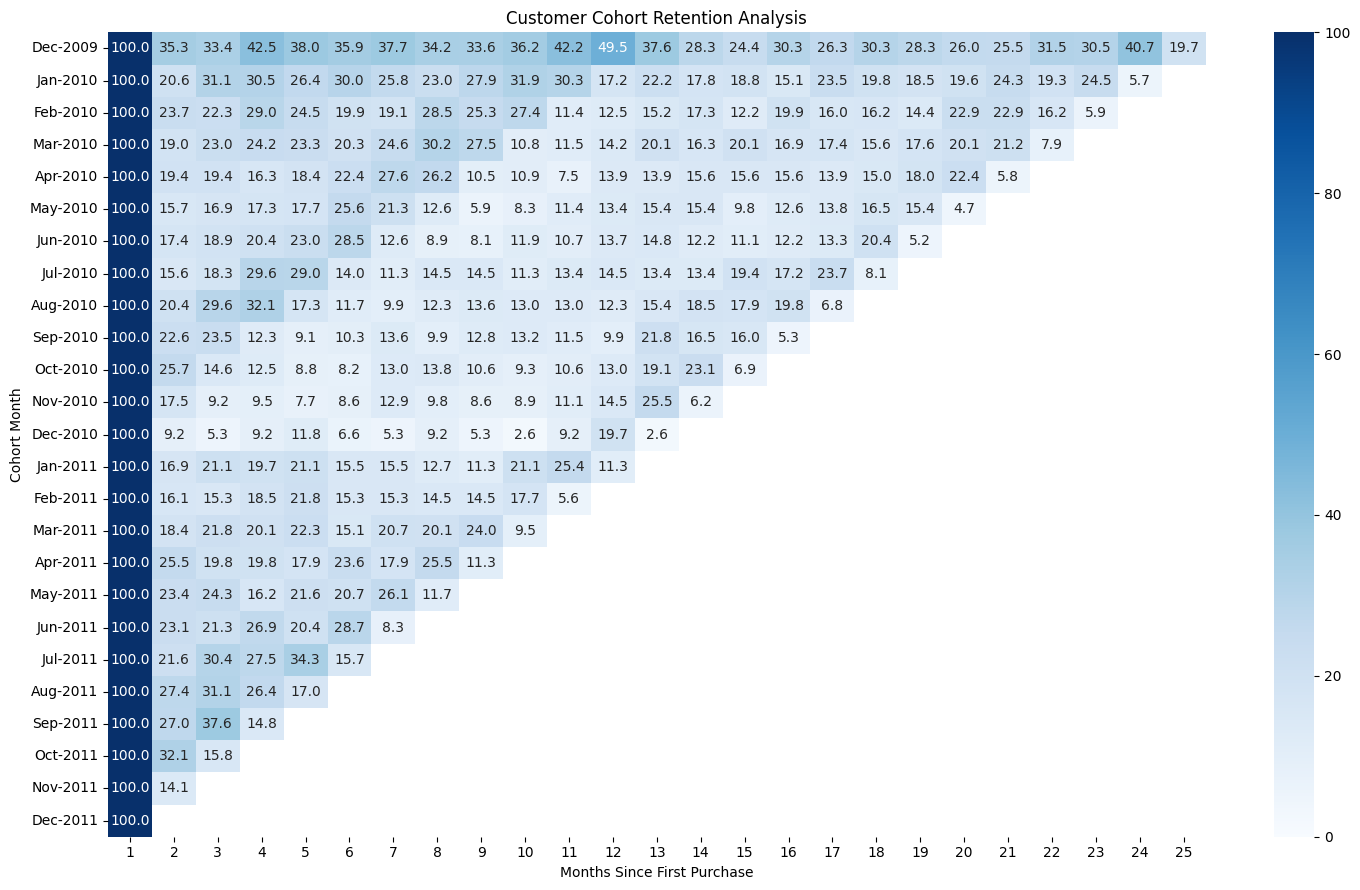

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

heatmap_data = cohort_retention.copy()

# Make cohort labels readable
heatmap_data.index = heatmap_data.index.strftime("%b-%Y")

plt.figure(figsize=(15, 9))

sns.heatmap(
    heatmap_data.round(1),
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.title("Customer Cohort Retention Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.tight_layout()

# Save the heatmap
plt.savefig(
    "/content/cohort_retention_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
print("Average retention by month:")
print(cohort_retention.mean().round(2))

print("\nNumber of customers in each cohort:")
print(cohort_table.iloc[:, 0])

Average retention by month:
CohortIndex
1     100.00
2      21.16
3      21.92
4      21.61
5      20.54
6      18.84
7      17.82
8      17.65
9      15.61
10     15.25
11     14.99
12     16.41
13     18.24
14     16.70
15     15.67
16     16.51
17     17.18
18     17.73
19     16.76
20     19.28
21     19.94
22     18.74
23     20.29
24     23.24
25     19.69
dtype: float64

Number of customers in each cohort:
CohortMonth
2009-12-01    955.0
2010-01-01    383.0
2010-02-01    376.0
2010-03-01    443.0
2010-04-01    294.0
2010-05-01    254.0
2010-06-01    270.0
2010-07-01    186.0
2010-08-01    162.0
2010-09-01    243.0
2010-10-01    377.0
2010-11-01    325.0
2010-12-01     76.0
2011-01-01     71.0
2011-02-01    124.0
2011-03-01    179.0
2011-04-01    106.0
2011-05-01    111.0
2011-06-01    108.0
2011-07-01    102.0
2011-08-01    106.0
2011-09-01    189.0
2011-10-01    221.0
2011-11-01    192.0
2011-12-01     28.0
Name: 1, dtype: float64


In [23]:
df_clean.to_csv(
    "/content/online_retail_cleaned.csv",
    index=False
)

print("CSV file created successfully")

CSV file created successfully


In [24]:
print(df_clean.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'ActivityMonth', 'CohortMonth', 'CohortIndex']
